# Unit 2: Linear Algebra & NumPy — Solutions

Today's goal: get comfortable with NumPy. By the end of this notebook you should be able to:
1. Create, reshape, slice, and index arrays
2. Use vectorized operations instead of loops
3. Perform matrix operations (dot product, transpose, multiply, inverse)
4. Compute distance metrics between vectors
5. Connect it back to regression from Unit 1

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

---
# Part 1: Why NumPy?

Python lists are flexible but slow. NumPy arrays are fast. How much does it matter?

## 1.1 The race

Task: square every element in a million-element array. Three approaches.

In [ ]:
data = np.random.rand(1_000_000)

# --- For loop ---
start = time.time()
squared_loop = []
for x in data:
    squared_loop.append(x ** 2)
loop_time = time.time() - start
print(f"For loop:           {loop_time:.4f}s")

In [ ]:
# --- Pandas apply ---
df_tmp = pd.DataFrame(data, columns=['val'])
start = time.time()
squared_apply = df_tmp['val'].apply(lambda x: x ** 2)
apply_time = time.time() - start
print(f"Pandas apply:       {apply_time:.4f}s")

In [ ]:
# --- NumPy vectorized ---
start = time.time()
squared_np = np.square(data)
np_time = time.time() - start
print(f"NumPy vectorized:   {np_time:.4f}s")

print(f"\nNumPy is ~{loop_time / np_time:.0f}x faster than a for loop")

**Why is NumPy so much faster?**

*Answer:* NumPy operations are implemented in compiled C code and operate on contiguous blocks of memory with a single data type. Python for loops have overhead on every iteration: type checking each element, looking up the `append` method, creating new Python objects. NumPy skips all of that by operating on the entire array at once in compiled code.

## 1.2 Your turn

Create a 1000 x 1000 random matrix and square every element using all three approaches. Benchmark each.

In [ ]:
mat = np.random.rand(1000, 1000)

# For loop
start = time.time()
result_loop = np.empty_like(mat)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        result_loop[i, j] = mat[i, j] ** 2
loop_time = time.time() - start
print(f"For loop:     {loop_time:.4f}s")

# Pandas apply
df_mat = pd.DataFrame(mat)
start = time.time()
result_apply = df_mat.apply(lambda col: col ** 2)
apply_time = time.time() - start
print(f"Pandas apply: {apply_time:.4f}s")

# NumPy
start = time.time()
result_np = np.square(mat)
np_time = time.time() - start
print(f"NumPy:        {np_time:.4f}s")

print(f"\nNumPy is ~{loop_time / np_time:.0f}x faster than a for loop")

---
# Part 2: NumPy Fundamentals

## 2.1 Creating arrays

In [ ]:
# From a list
v = np.array([1, 2, 3, 4, 5])
print("v:", v)
print("shape:", v.shape)
print("dtype:", v.dtype)

# 2D array
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print("\nA:\n", A)
print("shape:", A.shape)

In [ ]:
# Handy constructors
print("zeros:\n", np.zeros((2, 3)))
print("\nones:\n", np.ones((2, 3)))
print("\nidentity:\n", np.eye(3))
print("\narange:", np.arange(0, 10, 2))
print("\nlinspace:", np.linspace(0, 1, 5))

## 2.2 Reshaping

In [ ]:
arr = np.arange(1, 13)
print("Original:", arr, "| shape:", arr.shape)

reshaped = arr.reshape(3, 4)
print("\nReshaped to 3x4:\n", reshaped)

print("\nReshaped to 4x3:\n", arr.reshape(4, 3))

# -1 lets NumPy figure out one dimension
print("\nReshape with -1:\n", arr.reshape(2, -1))

**Predict:** What shape is `np.arange(24).reshape(2, 3, -1)`?

*Answer:* (2, 3, 4) — 24 elements total, 2 * 3 = 6, so the last dimension is 24/6 = 4.

In [ ]:
# Verify
np.arange(24).reshape(2, 3, -1).shape

## 2.2b Stacking and squeezing

`hstack` and `vstack` combine arrays horizontally and vertically. `squeeze` removes dimensions of size 1.

In [ ]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# hstack: combine side by side (horizontally)
print("hstack:", np.hstack([a, b]))

# vstack: stack on top of each other (vertically)
print("vstack:\n", np.vstack([a, b]))

# Works with 2D too
A = np.ones((2, 3))
B = np.zeros((2, 3))
print("\nvstack 2D:\n", np.vstack([A, B]))
print("\nhstack 2D:\n", np.hstack([A, B]))

In [ ]:
# squeeze: removes dimensions of size 1
c = np.array([[[1, 2, 3]]])  # shape (1, 1, 3)
print("Before squeeze:", c.shape)
print("After squeeze: ", c.squeeze().shape)
print("Values:", c.squeeze())

# Common use case: matrix multiply often gives (n, 1) when you want (n,)
result = np.array([[10], [20], [30]])  # shape (3, 1)
print("\nBefore squeeze:", result.shape)
print("After squeeze: ", result.squeeze().shape)

**Your turn:** Given these two arrays, use `vstack` to create a 4x3 matrix, then use `hstack` to create a 2x6 matrix.

```python
X = np.array([[1, 2, 3],
              [4, 5, 6]])
Y = np.array([[7, 8, 9],
              [10, 11, 12]])
```

In [ ]:
X = np.array([[1, 2, 3],
              [4, 5, 6]])
Y = np.array([[7, 8, 9],
              [10, 11, 12]])

print("vstack (4x3):\n", np.vstack([X, Y]))
print("shape:", np.vstack([X, Y]).shape)

print("\nhstack (2x6):\n", np.hstack([X, Y]))
print("shape:", np.hstack([X, Y]).shape)

## 2.3 Indexing and slicing

In [ ]:
M = np.arange(12).reshape(3, 4)
print("M:\n", M)
print("\nRow 0:", M[0])
print("Col 1:", M[:, 1])
print("Element (1,2):", M[1, 2])
print("Rows 0-1, Cols 2-3:\n", M[:2, 2:])

**Your turn:** From the matrix `M` above, extract:
1. The last row
2. The last column
3. The 2x2 submatrix in the bottom-right corner

In [ ]:
print("Last row:", M[-1])
print("Last column:", M[:, -1])
print("Bottom-right 2x2:\n", M[-2:, -2:])

## 2.4 Boolean masking

One of the most useful NumPy patterns: filter arrays using conditions.

In [ ]:
data = np.array([3, 7, 1, 9, 4, 6, 2, 8])

# The condition creates a boolean array
mask = data > 5
print("data:", data)
print("mask:", mask)
print("filtered:", data[mask])

**Your turn:** Given the array below, use boolean masking to:
1. Get all even numbers
2. Get all numbers between 10 and 20 (inclusive)
3. Replace all values greater than 15 with -1

In [ ]:
arr = np.array([2, 17, 8, 23, 11, 14, 6, 19, 25, 10])

# 1. Even numbers
print("Even:", arr[arr % 2 == 0])

# 2. Between 10 and 20
print("10-20:", arr[(arr >= 10) & (arr <= 20)])

# 3. Replace > 15 with -1
arr_copy = arr.copy()
arr_copy[arr_copy > 15] = -1
print("Replaced:", arr_copy)

## 2.5 Broadcasting

NumPy can operate on arrays of different shapes by "stretching" the smaller one.

In [ ]:
# Scalar broadcast
a = np.array([1, 2, 3])
print("a * 10:", a * 10)

# Row + column broadcast
row = np.array([1, 2, 3])
col = np.array([[10], [20], [30]])
print("\nrow + col:\n", row + col)

*Answer:* (3, 3). `row` has shape (3,) which broadcasts to (1, 3), and `col` has shape (3, 1). NumPy stretches the 1-dimensions: (3, 1) + (1, 3) = (3, 3). Each row gets each column value added.

## 2.6 Data types

In [ ]:
int_array = np.array([1, 0, 3, 5])
print("int:", int_array, "| dtype:", int_array.dtype)
print("float:", int_array.astype(float))
print("bool:", int_array.astype(bool))  # 0 -> False, nonzero -> True

# Memory matters at scale
big = np.random.rand(1_000_000)
print(f"\nfloat64: {big.nbytes / 1e6:.1f} MB")
print(f"float32: {big.astype(np.float32).nbytes / 1e6:.1f} MB")

---
# Part 3: Matrix Operations

## 3.1 Transpose

Flips rows and columns. If $A$ is $m \times n$, then $A^T$ is $n \times m$.

In [ ]:
B = np.arange(1, 13).reshape(3, 4)
print("B (3x4):\n", B)
print("\nB^T (4x3):\n", B.T)

## 3.2 Dot product

Two vectors: $a \cdot b = \sum_i a_i b_i$

In [ ]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("np.dot(a, b):", np.dot(a, b))
print("By hand: 1*4 + 2*5 + 3*6 =", 1*4 + 2*5 + 3*6)

## 3.3 Matrix multiplication

Each element in the result is a dot product of a row from A and a column from B.

**Shape rule:** $(m \times \mathbf{n}) \cdot (\mathbf{n} \times p) = (m \times p)$ — inner dimensions must match.

In [ ]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print("A @ B:\n", A @ B)

**Predict:** What is element (0, 1) of `A @ B`? Work it out by hand, then verify.

*Answer:* Row 0 of A is [1, 2], Col 1 of B is [6, 8]. Dot product: 1*6 + 2*8 = 22.

**Your turn:** For each pair, predict whether the multiplication works and the output shape. Then verify.

| A shape | B shape | Works? | Result shape |
|---------|---------|--------|--------------|
| (3, 4) | (4, 2) | ? | ? |
| (3, 4) | (3, 2) | ? | ? |
| (5, 3) | (3, 1) | ? | ? |
| (2, 2) | (2, 2) | ? | ? |

In [ ]:
# (3,4) @ (4,2) -> works, (3,2)
print("(3,4) @ (4,2):", (np.random.rand(3,4) @ np.random.rand(4,2)).shape)

# (3,4) @ (3,2) -> FAILS, inner dims 4 != 3
try:
    np.random.rand(3,4) @ np.random.rand(3,2)
except ValueError as e:
    print(f"(3,4) @ (3,2): ERROR - {e}")

# (5,3) @ (3,1) -> works, (5,1)
print("(5,3) @ (3,1):", (np.random.rand(5,3) @ np.random.rand(3,1)).shape)

# (2,2) @ (2,2) -> works, (2,2)
print("(2,2) @ (2,2):", (np.random.rand(2,2) @ np.random.rand(2,2)).shape)

## 3.4 Inverse

$A A^{-1} = I$ (the identity matrix). Only square matrices can have an inverse, and not all do.

In [ ]:
A = np.array([[2, 1],
              [5, 3]])

A_inv = np.linalg.inv(A)
print("A:\n", A)
print("\nA inverse:\n", A_inv)
print("\nA @ A_inv:\n", np.round(A @ A_inv, 10))

**Try it:** What happens with `np.linalg.inv(np.array([[1, 2], [2, 4]]))`? Why?

In [ ]:
try:
    np.linalg.inv(np.array([[1, 2], [2, 4]]))
except np.linalg.LinAlgError as e:
    print(f"Error: {e}")

*Answer:* It raises a `LinAlgError: Singular matrix`. Row 2 is exactly 2x row 1, so the rows are linearly dependent. The matrix has no inverse because it maps multiple inputs to the same output — you can't uniquely reverse it.

---
# Part 4: Distances

Many algorithms (kNN, clustering, embeddings) rely on measuring distance between points. Let's implement three common ones using only NumPy.

In [ ]:
point1 = np.array([1, 2])
point2 = np.array([4, 6])

**Your turn:** Write functions for each. No built-in distance functions — use the NumPy operations you've learned.

1. **Euclidean distance**: $d = \sqrt{\sum_i (a_i - b_i)^2}$
2. **Manhattan distance**: $d = \sum_i |a_i - b_i|$
3. **Cosine similarity**: $\cos(\theta) = \frac{a \cdot b}{\|a\| \|b\|}$

In [ ]:
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

print("Euclidean:", euclidean(point1, point2))
# Expected: sqrt((4-1)^2 + (6-2)^2) = sqrt(9+16) = 5.0

In [ ]:
def manhattan(a, b):
    return np.sum(np.abs(a - b))

print("Manhattan:", manhattan(point1, point2))
# Expected: |4-1| + |6-2| = 3 + 4 = 7

In [ ]:
def cosine_sim(a, b):
    return np.dot(a, b) / (np.sqrt(np.sum(a ** 2)) * np.sqrt(np.sum(b ** 2)))

print("Cosine similarity:", cosine_sim(point1, point2))

**Quick check:** Cosine similarity is 1 when vectors point the same direction, 0 when perpendicular, -1 when opposite. What's the cosine similarity of `[1, 0]` and `[0, 1]`? Verify with your function.

In [ ]:
print("Perpendicular:", cosine_sim(np.array([1, 0]), np.array([0, 1])))
# Expected: 0.0 — the vectors are perpendicular

print("Same direction:", cosine_sim(np.array([1, 0]), np.array([3, 0])))
# Expected: 1.0

print("Opposite:", cosine_sim(np.array([1, 0]), np.array([-5, 0])))
# Expected: -1.0

---
# Part 5: Connecting to Regression

In Unit 1 you used `statsmodels` to fit regressions. Now let's see that regression is just the NumPy operations you learned today.

## 5.1 Generate data

We'll simulate data where we know the true answer: $y = 5 + 3x + \epsilon$, where $\epsilon \sim N(0, 10)$.

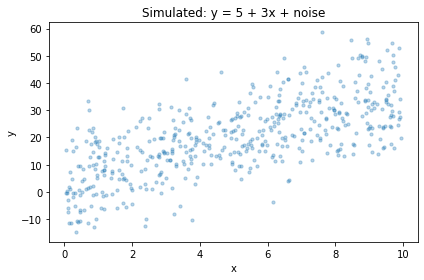

In [2]:
np.random.seed(42)
n = 500

beta_0_true = 5
beta_1_true = 3

x = np.random.rand(n) * 10
noise = np.random.normal(0, 10, n)
y = beta_0_true + beta_1_true * x + noise

plt.scatter(x, y, alpha=0.3, s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Simulated: y = {beta_0_true} + {beta_1_true}x + noise')
plt.tight_layout()

## 5.2 Compute betas with NumPy

You have these formulas:

$$\hat{\beta}_1 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

**Your turn:** Compute $\hat{\beta}_0$ and $\hat{\beta}_1$ using NumPy operations (no loops). Print them.

In [3]:
x_mean = np.mean(x)
y_mean = np.mean(y)

beta_1_hat = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
beta_0_hat = y_mean - beta_1_hat * x_mean

print(f"beta_0_hat: {beta_0_hat:.4f}  (true: {beta_0_true})")
print(f"beta_1_hat: {beta_1_hat:.4f}  (true: {beta_1_true})")

beta_0_hat: 3.9295  (true: 5)
beta_1_hat: 3.2300  (true: 3)


## 5.3 Compare with statsmodels

Now fit the same model with `sm.OLS` like you did in Unit 1. Do your betas match?

In [4]:
X_sm = sm.add_constant(x)
model = sm.OLS(y, X_sm).fit()

print("statsmodels coefficients:")
print(f"  const: {model.params[0]:.4f}")
print(f"  x:     {model.params[1]:.4f}")

print(f"\nOur NumPy coefficients:")
print(f"  beta_0: {beta_0_hat:.4f}")
print(f"  beta_1: {beta_1_hat:.4f}")

print(f"\nMatch: {np.allclose(model.params, [beta_0_hat, beta_1_hat])}")

statsmodels coefficients:
  const: 3.9295
  x:     3.2300

Our NumPy coefficients:
  beta_0: 3.9295
  beta_1: 3.2300

Match: True


## 5.4 Sample size and estimation

**Your turn:** 
1. Write a function `estimate_beta1(n)` that generates data from $y = 5 + 3x + \epsilon$, computes $\hat{\beta}_1$, and returns it.
2. For sample sizes `[20, 50, 100, 500, 1000, 5000]`, run the function 100 times each.
3. Plot all estimates as a scatter: x-axis is sample size, y-axis is $\hat{\beta}_1$. Add a horizontal line at the true value (3).

What do you observe?

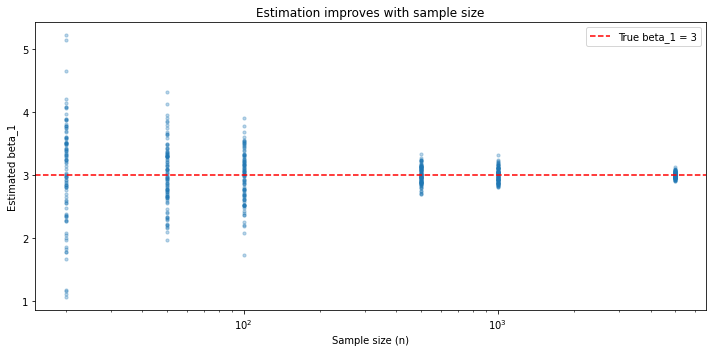

In [5]:
def estimate_beta1(n):
    x = np.random.rand(n) * 10
    noise = np.random.normal(0, 10, n)
    y = 5 + 3 * x + noise
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    beta1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    return beta1

sample_sizes = [20, 50, 100, 500, 1000, 5000]
n_reps = 100

results = []
for s in sample_sizes:
    for _ in range(n_reps):
        results.append({'n': s, 'beta1_hat': estimate_beta1(s)})

df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
plt.scatter(df_results['n'], df_results['beta1_hat'], alpha=0.3, s=10)
plt.axhline(y=3, color='red', linestyle='--', label='True beta_1 = 3')
plt.xlabel('Sample size (n)')
plt.ylabel('Estimated beta_1')
plt.title('Estimation improves with sample size')
plt.xscale('log')
plt.legend()
plt.tight_layout()

*Interpretation:* As sample size increases, the estimates of beta_1 cluster more tightly around the true value of 3. With n=20, the estimates are scattered widely (some are quite far from 3). By n=5000, they're almost all very close to 3. This demonstrates the law of large numbers — more data gives us more precise estimates. The estimates are centered on the truth at all sample sizes (unbiased), but the variance of the estimates shrinks with more data.